In [21]:
# %% 
# FINAL NA SANA
# ===============================
# Siamese Signature Verification (CPU-optimized)
# Using MobileNetV2 + Cached Numpy Images
# ===============================

import os
import random
import json
import pickle
import numpy as np
from tqdm import tqdm
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

import cv2
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers, callbacks
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [22]:
# %% 
# ---------- 1) CONFIG ----------
IMG_SIZE = (224,224)
BATCH_SIZE = 32
EMBED_DIM = 256
MARGIN = 1.0
EPOCHS = 20
STEPS_PER_EPOCH = 100
VAL_STEPS = 50

MODEL_DIR = "FinishLine"
os.makedirs(MODEL_DIR, exist_ok=True)
WEIGHTS_PATH = os.path.join(MODEL_DIR, "siamese_best.keras")
EMBEDDING_PKL = os.path.join(MODEL_DIR, "embeddings_signet.pkl")
IMG_CACHE_NPY_TRAIN = os.path.join(MODEL_DIR, "image_cache_train.npy")
IMG_KEYS_PKL_TRAIN = os.path.join(MODEL_DIR, "image_keys_train.pkl")
IMG_CACHE_NPY_VAL   = os.path.join(MODEL_DIR, "image_cache_val.npy")
IMG_KEYS_PKL_VAL   = os.path.join(MODEL_DIR, "image_keys_val.pkl")
IMG_CACHE_NPY_TEST   = os.path.join(MODEL_DIR, "image_cache_test.npy")
IMG_KEYS_PKL_TEST   = os.path.join(MODEL_DIR, "image_keys_test.pkl")
METRICS_NPZ = os.path.join(MODEL_DIR, "metrics_signet.npz")
THRESHOLDS_JSON = os.path.join(MODEL_DIR, "thresholds_signet.json")
EMBEDDING_MODEL_PATH = os.path.join(MODEL_DIR, "embedding_signet.keras")

In [23]:
# %% 
# ---------- 2) PREPROCESSING ----------
def preprocess_signature_image(img_path):
    img = cv2.imread(img_path)
    if img is None:
        raise ValueError(f"❌ Failed to read image: {img_path}")

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray_blur = cv2.GaussianBlur(gray, (31,31), 0)
    corrected = cv2.divide(gray, gray_blur, scale=255)
    clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8,8))
    enhanced = clahe.apply(corrected)
    highpass = cv2.subtract(enhanced, cv2.GaussianBlur(enhanced,(9,9),0))
    sharpened = cv2.addWeighted(enhanced,0.8,highpass,0.5,0)

    _, thresh = cv2.threshold(sharpened,0,255,cv2.THRESH_BINARY_INV+cv2.THRESH_OTSU)
    contours,_ = cv2.findContours(thresh, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    if contours:
        pts = np.vstack(contours)
        x,y,w,h = cv2.boundingRect(pts)
        pad = 0.12
        x1 = max(0,int(x - w*pad))
        y1 = max(0,int(y - h*pad))
        x2 = min(gray.shape[1], int(x + w*(1+pad)))
        y2 = min(gray.shape[0], int(y + h*(1+pad)))
        cropped = img[y1:y2, x1:x2]
    else:
        cropped = img

    resized = cv2.resize(cropped, IMG_SIZE)
    rgb = cv2.cvtColor(resized, cv2.COLOR_BGR2RGB)
    cnn_ready = rgb.astype(np.float32)
    cnn_ready = (cnn_ready - 127.5)/127.5
    return cnn_ready


def load_image(img_path):
    return preprocess_signature_image(img_path)

In [24]:
# %% 
# ---------- 3) LOAD DATASET ----------
def load_dataset_split(root_folder):
    person_map = {}
    for user_folder in sorted(os.listdir(root_folder)):
        u_path = os.path.join(root_folder, user_folder)
        if not os.path.isdir(u_path): continue

        images = []
        for sub in ["genuine","forged"]:
            sp = os.path.join(u_path, sub)
            if not os.path.exists(sp): continue
            for f in os.listdir(sp):
                if f.lower().endswith(('.png','.jpg','.jpeg')):
                    images.append(os.path.join(sp,f))
        person_map[user_folder] = images
    return person_map

train_map = load_dataset_split("dataset/00 Training")
val_map   = load_dataset_split("dataset/01 Validation")
test_map  = load_dataset_split("dataset/02 Testing")

for name,dataset in zip(["TRAIN","VAL","TEST"], [train_map,val_map,test_map]):
    n_persons = len(dataset)
    n_images = sum(len(imgs) for imgs in dataset.values())
    print(f"{name}: {n_persons} persons, {n_images} images")

TRAIN: 38 persons, 1824 images
VAL: 8 persons, 384 images
TEST: 9 persons, 432 images


In [25]:
# -----------------------------
# 4) CACHE PREPROCESSED IMAGES (Memory-efficient)
# -----------------------------
def cache_images_memmap(person_map, cache_npy, keys_pkl):
    """
    Memory-efficient caching using np.memmap.
    Returns dict {image_path: index_in_memmap}.
    """
    all_paths = [(pid, p) for pid, paths in person_map.items() for p in paths]

    # Load existing cache if available
    if os.path.exists(cache_npy) and os.path.exists(keys_pkl):
        with open(keys_pkl, "rb") as f:
            keys = pickle.load(f)
        print(f"✅ Loaded cache metadata for {len(keys)} images: {cache_npy}")
        # Open memmap read-only
        memmap_array = np.memmap(cache_npy, dtype=np.float32, mode='r', shape=(len(keys), *IMG_SIZE, 3))
        return {k: memmap_array[i] for i, k in enumerate(keys)}

    # Otherwise, create new memmap
    total_images = len(all_paths)
    memmap_array = np.memmap(cache_npy, dtype=np.float32, mode='w+', shape=(total_images, *IMG_SIZE, 3))
    keys = []
    idx = 0

    for pid, path in tqdm(all_paths, desc=f"Caching images to {cache_npy}"):
        try:
            img = load_image(path)
        except Exception as e:
            print(f"⚠️ Skipping image {path}: {e}")
            continue

        if img.shape != (*IMG_SIZE, 3):
            print(f"⚠️ Skipping image {path}: unexpected shape {img.shape}")
            continue

        memmap_array[idx] = img
        keys.append(path)
        idx += 1

    # Resize memmap to actual number of cached images
    memmap_array.flush()
    np.save(cache_npy.replace(".npy", "_shape.npy"), np.array([idx], dtype=np.int32))  # store actual count
    with open(keys_pkl, "wb") as f:
        pickle.dump(keys, f)

    print(f"✅ Cached {len(keys)} images to {cache_npy}")
    return {k: memmap_array[i] for i, k in enumerate(keys)}

# -----------------------------
# Usage
# -----------------------------
img_arrays_train = cache_images_memmap(train_map, IMG_CACHE_NPY_TRAIN, IMG_KEYS_PKL_TRAIN)
img_arrays_val   = cache_images_memmap(val_map,   IMG_CACHE_NPY_VAL,   IMG_KEYS_PKL_VAL)
img_arrays_test  = cache_images_memmap(test_map,  IMG_CACHE_NPY_TEST,  IMG_KEYS_PKL_TEST)


✅ Loaded cache metadata for 1824 images: FinishLine\image_cache_train.npy
✅ Loaded cache metadata for 384 images: FinishLine\image_cache_val.npy
✅ Loaded cache metadata for 432 images: FinishLine\image_cache_test.npy


In [26]:
import random
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers

# -----------------------------
# Data Augmentation
# -----------------------------
def build_augmentation():
    return tf.keras.Sequential([
        layers.RandomRotation(0.08),
        layers.RandomTranslation(0.08, 0.08),
        layers.RandomZoom(0.08),
        layers.RandomContrast(0.3),
        layers.RandomBrightness(0.3),
    ], name="signature_augmentation")


# -----------------------------
# Pair Generator with Multi Cross-Writer Negatives
# -----------------------------
def pair_generator_advanced(person_map, cache, batch_size=32, cross_negatives=5):
    """
    Generate training pairs for Siamese network.

    Args:
        person_map: dict {person_id: [image_paths]}
        cache: dict {image_path: np.array}
        batch_size: number of pairs per batch
        cross_negatives: number of random cross-writer negatives per batch iteration
    """
    writers = list(person_map.keys())
    augment = build_augmentation()

    while True:
        A, B, L = [], [], []

        for _ in range(batch_size):
            choice = random.random()

            # -----------------------------
            # 1. Positive pairs (genuine-genuine same writer)
            # -----------------------------
            if choice < 0.33:
                pid = random.choice(writers)
                imgs = person_map[pid]
                genuine = [p for p in imgs if "genuine" in p.lower()]
                if len(genuine) >= 2:
                    p1, p2 = random.sample(genuine, 2)
                    label = 1
                else:
                    continue

            # -----------------------------
            # 2. Negative same-writer (genuine-forged)
            # -----------------------------
            elif choice < 0.66:
                pid = random.choice(writers)
                imgs = person_map[pid]
                genuine = [p for p in imgs if "genuine" in p.lower()]
                forged = [p for p in imgs if "forged" in p.lower()]
                if genuine and forged:
                    p1 = random.choice(genuine)
                    p2 = random.choice(forged)
                    label = 0
                else:
                    continue

            # -----------------------------
            # 3. Negative cross-writer (random pairs)
            # -----------------------------
            else:
                for _ in range(cross_negatives):
                    pid1, pid2 = random.sample(writers, 2)
                    imgs1 = person_map[pid1]
                    imgs2 = person_map[pid2]
                    p1 = random.choice(imgs1)
                    p2 = random.choice(imgs2)
                    imgA = tf.cast(cache[p1], tf.float32)
                    imgB = tf.cast(cache[p2], tf.float32)
                    imgA = augment(imgA)
                    imgB = augment(imgB)
                    A.append(imgA)
                    B.append(imgB)
                    L.append(0)
                continue  # skip the rest of this iteration

            # -----------------------------
            # Apply augmentation for positive & same-writer negative
            # -----------------------------
            imgA = tf.cast(cache[p1], tf.float32)
            imgB = tf.cast(cache[p2], tf.float32)
            imgA = augment(imgA)
            imgB = augment(imgB)
            A.append(imgA)
            B.append(imgB)
            L.append(label)

        yield (np.array(A), np.array(B)), np.array(L).astype("float32")


In [27]:
import tensorflow as tf
from tensorflow.keras import layers, Model, optimizers
from tensorflow.keras.applications import MobileNetV2

# -----------------------------
# CONFIG
# -----------------------------
EMBED_DIM = 256
MARGIN = 1.0
DROPOUT_RATE = 0.4  # Slightly higher to reduce overfitting
FINE_TUNE_LAYERS = 50  # More layers to fine-tune

# -----------------------------
# CUSTOM LAYERS (NO LAMBDA)
# -----------------------------
class L2NormalizationLayer(layers.Layer):
    def call(self, x):
        return tf.math.l2_normalize(x, axis=1)

class L2DistanceLayer(layers.Layer):
    def call(self, inputs):
        x, y = inputs
        return tf.reduce_sum(tf.square(x - y), axis=1, keepdims=True)

# -----------------------------
# BUILD BACKBONE (NO LAMBDA)
# -----------------------------
def build_backbone():
    base = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(224,224,3)
    )

    # Freeze all layers except the last FINE_TUNE_LAYERS
    for layer in base.layers[:-FINE_TUNE_LAYERS]:
        layer.trainable = False
    for layer in base.layers[-FINE_TUNE_LAYERS:]:
        layer.trainable = True

    x = layers.GlobalAveragePooling2D()(base.output)

    # Embedding head
    x = layers.Dense(512, activation=None)(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.Dropout(DROPOUT_RATE)(x)
    x = layers.Dense(EMBED_DIM, activation=None)(x)

    # Final L2 normalization
    x = L2NormalizationLayer()(x)

    return Model(base.input, x, name="embedding_backbone")

backbone = build_backbone()

# -----------------------------
# BUILD SIAMESE NETWORK
# -----------------------------
inputA = layers.Input((224,224,3))
inputB = layers.Input((224,224,3))

embA = backbone(inputA)
embB = backbone(inputB)

dist = L2DistanceLayer()([embA, embB])

siamese_model = Model([inputA, inputB], dist)

# -----------------------------
# CONTRASTIVE LOSS
# -----------------------------
def contrastive_loss(y_true, y_pred):
    y_true = tf.cast(y_true, tf.float32)
    distances = tf.sqrt(y_pred + 1e-12)

    positive_loss = y_true * tf.square(distances)
    negative_loss = (1 - y_true) * tf.square(tf.maximum(MARGIN - distances, 0))

    return tf.reduce_mean(positive_loss + negative_loss)

# -----------------------------
# COMPILE MODEL
# -----------------------------
siamese_model.compile(
    optimizer=optimizers.Adam(1e-4),
    loss=contrastive_loss
)

siamese_model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_4       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embedding_backbone  │ (None, 256)       │  3,047,232 │ input_layer_4[0]… │
│ (Functional)        │                   │            │ input_layer_5[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ l2_distance_layer_1 │ (None, 1)         │          0 │ embedding_backbo… │
│ (L2DistanceLayer)   │                   │            │ embedding_backbo… │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 3,047,232 (11.62 MB)

 Trainable params: 2,643,328 (10.08 MB)

 Non-trainable params: 403,904 (1.54 MB)

In [28]:
from tensorflow.keras.utils import register_keras_serializable
import tensorflow as tf

@register_keras_serializable()
class L2NormalizationLayer(tf.keras.layers.Layer):
    def call(self, inputs):
        return tf.math.l2_normalize(inputs, axis=1)


In [29]:
import os
from tensorflow.keras.models import load_model

MODEL_PATH = "FinishLine/embedding_signet.keras"

if os.path.exists(MODEL_PATH):
    print(f"Found pretrained model at: {MODEL_PATH}")
    embedding_model = load_model(
        MODEL_PATH,
        custom_objects={"L2NormalizationLayer": L2NormalizationLayer}
    )
    print("Model loaded successfully. Skipping training.")
    SKIP_TRAINING = True
else:
    print("No pretrained embedding model found. Training will run.")
    SKIP_TRAINING = False


Found pretrained model at: FinishLine/embedding_signet.keras
Model loaded successfully. Skipping training.


In [30]:
if not SKIP_TRAINING:
    train_gen = pair_generator_advanced(train_map, img_arrays_train, BATCH_SIZE)
    val_gen   = pair_generator_advanced(val_map,   img_arrays_val,   BATCH_SIZE)

    cb = [
        callbacks.ModelCheckpoint(WEIGHTS_PATH, save_best_only=True, monitor="val_loss"),
        callbacks.ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=3),
        callbacks.EarlyStopping(monitor="val_loss", patience=6, restore_best_weights=True)
    ]

    siamese_model.fit(
        train_gen,
        steps_per_epoch=STEPS_PER_EPOCH,
        validation_data=val_gen,
        validation_steps=VAL_STEPS,
        epochs=EPOCHS,
        callbacks=cb
    )

    backbone.save(EMBEDDING_MODEL_PATH)
    print("Saved:", EMBEDDING_MODEL_PATH)
else:
    print("Training skipped.")


Training skipped.


In [31]:
# %% 
# ---------- 7) PRECOMPUTE EMBEDDINGS (Updated Lambda-free) ----------
import os
import pickle
from tqdm import tqdm
import numpy as np
import tensorflow as tf

def precompute_embeddings(
    person_to_images,
    img_cache,
    embedding_model,
    cache_path=EMBEDDING_PKL,
    normalize=True,
    augment=False
):
    """
    Compute embeddings for all images using the lambda-free backbone.

    Args:
        person_to_images: dict {person_id: [image_paths]}
        img_cache: dict {image_path: np.array}
        embedding_model: trained L2-normalized backbone
        cache_path: path to save embeddings
        normalize: whether to apply L2 normalization to embeddings
        augment: whether to apply augmentation (for extra robustness)

    Returns:
        embeddings: dict {image_path: embedding_vector}
    """
    embeddings = {}

    # Build augmentation once if requested
    if augment:
        augmentation = tf.keras.Sequential([
            layers.RandomRotation(0.05),
            layers.RandomTranslation(0.05, 0.05),
            layers.RandomZoom(0.05),
            layers.RandomContrast(0.2),
            layers.RandomBrightness(0.2),
        ], name="embedding_augmentation")
    else:
        augmentation = lambda x: x  # identity

    for pid, paths in tqdm(person_to_images.items(), desc="Precomputing embeddings"):
        for p in paths:
            if p not in img_cache:
                print(f"⚠️ Missing cached img: {p}")
                continue

            # Get image array
            img = tf.cast(img_cache[p], tf.float32)
            img = augmentation(img)
            img = np.expand_dims(img, axis=0)  # model expects (1,224,224,3)

            # Predict embedding
            emb = embedding_model.predict(img, verbose=0)[0]

            # Optional L2 normalization (safe for cosine similarity)
            if normalize:
                emb = emb / (np.linalg.norm(emb) + 1e-12)

            embeddings[p] = emb

    # Save embeddings
    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, "wb") as f:
        pickle.dump(embeddings, f)

    print(f"✅ Saved {len(embeddings)} embeddings → {cache_path}")
    return embeddings

# -----------------------------
# USAGE EXAMPLE (PRECOMPUTE ALL SPLITS)
# -----------------------------
EMBEDDING_DIR = "embeddings"
os.makedirs(EMBEDDING_DIR, exist_ok=True)

# --- Train embeddings ---
train_path = os.path.join(EMBEDDING_DIR, "embeddings_train.pkl")
if not os.path.exists(train_path):
    print("Generating embeddings for train set...")
    embeddings_train = precompute_embeddings(train_map, img_arrays_train, backbone, cache_path=train_path)
else:
    print("Loading existing train embeddings...")
    with open(train_path, "rb") as f:
        embeddings_train = pickle.load(f)
print(f"Loaded {len(embeddings_train)} train embeddings.")

# --- Validation embeddings ---
val_path = os.path.join(EMBEDDING_DIR, "embeddings_val.pkl")
if not os.path.exists(val_path):
    print("Generating embeddings for validation set...")
    embeddings_val = precompute_embeddings(val_map, img_arrays_val, backbone, cache_path=val_path)
else:
    print("Loading existing validation embeddings...")
    with open(val_path, "rb") as f:
        embeddings_val = pickle.load(f)
print(f"Loaded {len(embeddings_val)} validation embeddings.")

# --- Test embeddings ---
test_path = os.path.join(EMBEDDING_DIR, "embeddings_test.pkl")
if not os.path.exists(test_path):
    print("Generating embeddings for test set...")
    embeddings_test = precompute_embeddings(test_map, img_arrays_test, backbone, cache_path=test_path)
else:
    print("Loading existing test embeddings...")
    with open(test_path, "rb") as f:
        embeddings_test = pickle.load(f)
print(f"Loaded {len(embeddings_test)} test embeddings.")


Loading existing train embeddings...
Loaded 1824 train embeddings.
Loading existing validation embeddings...
Loaded 384 validation embeddings.
Loading existing test embeddings...
Loaded 432 test embeddings.


In [32]:
# %% 
# ---------- 8) COMPUTE SIMILARITY SCORES ----------

from scipy.spatial.distance import cosine, euclidean, cityblock
import itertools
import random

def compute_similarity_scores(person_map, embeddings_dict, cross_pairs_per_writer=10):
    all_pairs, y_true = [], []
    scores_cos, scores_eu, scores_man = [], [], []

    writers = list(person_map.keys())
    print("Generating all pair types and computing similarity scores...")

    for pid, imgs in tqdm(person_map.items(), desc="Processing persons"):
        genuine = [p for p in imgs if "genuine" in p.lower()]
        forged = [p for p in imgs if "forged" in p.lower()]

        # Positive pairs
        for img1, img2 in itertools.combinations(genuine, 2):
            embA, embB = embeddings_dict[img1], embeddings_dict[img2]
            all_pairs.append((img1, img2))
            y_true.append(1)
            scores_cos.append(1 - cosine(embA, embB))
            scores_eu.append(euclidean(embA, embB))
            scores_man.append(cityblock(embA, embB))

        # Negative pairs (same writer)
        for g in genuine:
            for f in forged:
                embA, embB = embeddings_dict[g], embeddings_dict[f]
                all_pairs.append((g, f))
                y_true.append(0)
                scores_cos.append(1 - cosine(embA, embB))
                scores_eu.append(euclidean(embA, embB))
                scores_man.append(cityblock(embA, embB))

    # Negative cross-user pairs
    for pid1 in tqdm(writers, desc="Cross-user negatives"):
        imgs1 = person_map[pid1]
        for _ in range(cross_pairs_per_writer):
            pid2 = random.choice([w for w in writers if w != pid1])
            imgs2 = person_map[pid2]
            p1, p2 = random.choice(imgs1), random.choice(imgs2)
            embA, embB = embeddings_dict[p1], embeddings_dict[p2]
            all_pairs.append((p1, p2))
            y_true.append(0)
            scores_cos.append(1 - cosine(embA, embB))
            scores_eu.append(euclidean(embA, embB))
            scores_man.append(cityblock(embA, embB))

    return all_pairs, np.array(y_true), np.array(scores_cos), np.array(scores_eu), np.array(scores_man)

# Compute validation similarity scores for threshold search
all_pairs_val, y_true_val, scores_cos_val, scores_eu_val, scores_man_val = compute_similarity_scores(
    val_map, embeddings_val, cross_pairs_per_writer=10
)


Generating all pair types and computing similarity scores...


Cross-user negatives: 100%|██████████| 8/8 [00:00<00:00, 2298.25it/s]


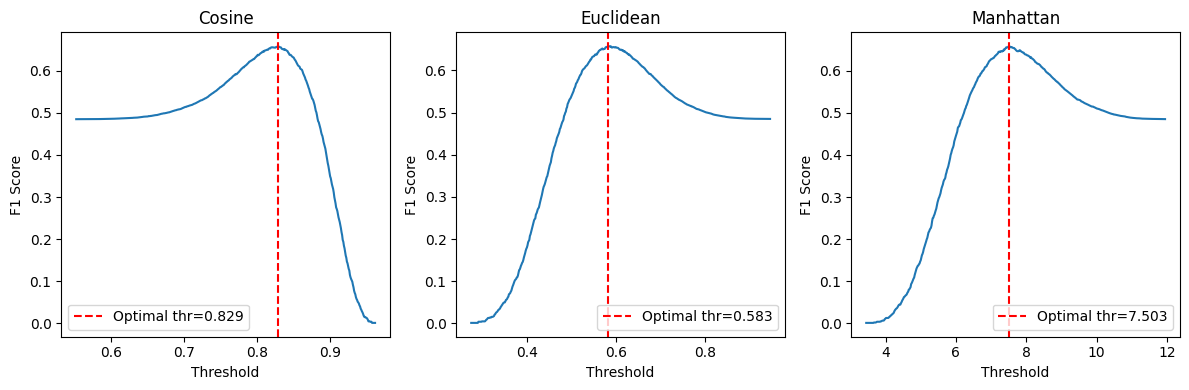

In [33]:
# %% 
# ---------- 9) THRESHOLD SEARCH ON VALIDATION ----------

from sklearn.metrics import f1_score, accuracy_score
import matplotlib.pyplot as plt
import json

def evaluate_thresholds(y_true, scores, is_similarity=True, num_thresholds=500):
    thresholds = np.linspace(np.min(scores), np.max(scores), num_thresholds)
    best_thr, best_f1, best_metrics, f1_vals = None, -1, {}, []

    for thr in thresholds:
        y_pred = (scores >= thr).astype(int) if is_similarity else (scores <= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        f1_vals.append(f1)
        acc = accuracy_score(y_true, y_pred)
        far = np.sum((y_pred == 1) & (y_true == 0)) / max(1, np.sum(y_true == 0))
        frr = np.sum((y_pred == 0) & (y_true == 1)) / max(1, np.sum(y_true == 1))
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
            best_metrics = {"F1": f1, "Accuracy": acc, "FAR": far, "FRR": frr}

    return best_thr, best_metrics, thresholds, np.array(f1_vals)

# Find thresholds from validation set
thr_cos, metrics_cos_val, thr_vals_cos, f1_vals_cos = evaluate_thresholds(y_true_val, scores_cos_val, True)
thr_eu, metrics_eu_val, thr_vals_eu, f1_vals_eu = evaluate_thresholds(y_true_val, scores_eu_val, False)
thr_man, metrics_man_val, thr_vals_man, f1_vals_man = evaluate_thresholds(y_true_val, scores_man_val, False)

# Save thresholds
thresholds_dict = {"cosine": float(thr_cos), "euclidean": float(thr_eu), "manhattan": float(thr_man)}
with open("thresholds_optimal.json", "w") as f:
    json.dump(thresholds_dict, f, indent=4)

# Optional F1 vs threshold plots
plt.figure(figsize=(12,4))
for idx, (thr_vals, f1_vals, thr_opt, title) in enumerate(
    [(thr_vals_cos, f1_vals_cos, thr_cos, "Cosine"),
     (thr_vals_eu, f1_vals_eu, thr_eu, "Euclidean"),
     (thr_vals_man, f1_vals_man, thr_man, "Manhattan")]):
    plt.subplot(1,3,idx+1)
    plt.plot(thr_vals, f1_vals)
    plt.axvline(thr_opt, color='red', linestyle='--', label=f'Optimal thr={thr_opt:.3f}')
    plt.title(title)
    plt.xlabel("Threshold")
    plt.ylabel("F1 Score")
    plt.legend()
plt.tight_layout()
plt.show()


================== new =====================

Cross-user negatives: 100%|██████████| 9/9 [00:00<00:00, 1769.83it/s]



=== Validation Thresholds ===
Cosine: 0.828506, Euclidean: 0.584854, Manhattan: 7.523941

=== Final Evaluation on Test Set ===

--- Cosine ---
F1: 0.8153
Precision: 0.6971
Recall: 0.9819
Accuracy: 0.8576
FAR: 0.2010
FRR: 0.0181

--- Euclidean ---
F1: 0.8165
Precision: 0.6989
Recall: 0.9819
Accuracy: 0.8587
FAR: 0.1993
FRR: 0.0181

--- Manhattan ---
F1: 0.8042
Precision: 0.6796
Recall: 0.9847
Accuracy: 0.8465
FAR: 0.2186
FRR: 0.0153


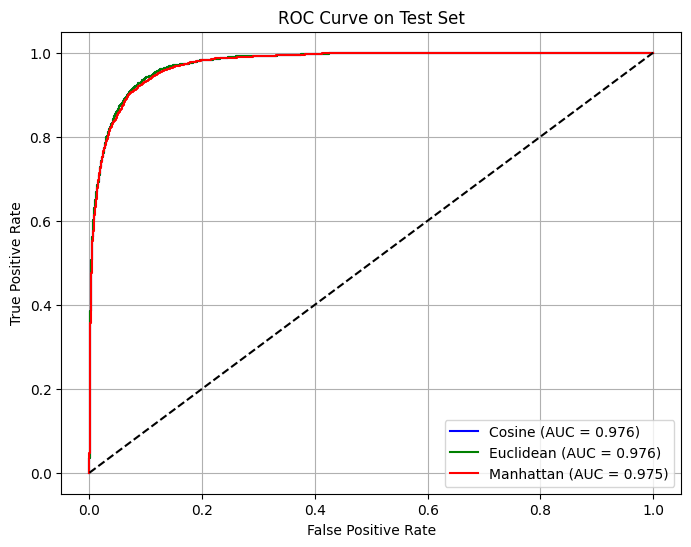

In [34]:
# %% 
# ---------- PRECOMPUTE EMBEDDINGS FOR VAL & TEST ----------
import os
import pickle
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers
from tqdm import tqdm

def precompute_embeddings(person_to_images, img_cache, embedding_model, cache_path, normalize=True, augment=False):
    embeddings = {}
    if augment:
        augmentation = tf.keras.Sequential([
            layers.RandomRotation(0.05),
            layers.RandomTranslation(0.05, 0.05),
            layers.RandomZoom(0.05),
            layers.RandomContrast(0.2),
            layers.RandomBrightness(0.2),
        ])
    else:
        augmentation = lambda x: x

    for pid, paths in tqdm(person_to_images.items(), desc="Precomputing embeddings"):
        for p in paths:
            if p not in img_cache:
                print(f"⚠️ Missing cached img: {p}")
                continue
            img = tf.cast(img_cache[p], tf.float32)
            img = augmentation(img)
            img = np.expand_dims(img, axis=0)
            emb = embedding_model.predict(img, verbose=0)[0]
            if normalize:
                emb = emb / (np.linalg.norm(emb) + 1e-12)
            embeddings[p] = emb

    os.makedirs(os.path.dirname(cache_path), exist_ok=True)
    with open(cache_path, "wb") as f:
        pickle.dump(embeddings, f)
    print(f"✅ Saved {len(embeddings)} embeddings → {cache_path}")
    return embeddings

# Load or recompute embeddings
EMBEDDING_DIR = "embeddings"
os.makedirs(EMBEDDING_DIR, exist_ok=True)

val_path = os.path.join(EMBEDDING_DIR, "embeddings_val.pkl")
if not os.path.exists(val_path):
    embeddings_val = precompute_embeddings(val_map, img_arrays_val, backbone, cache_path=val_path)
else:
    with open(val_path, "rb") as f:
        embeddings_val = pickle.load(f)

test_path = os.path.join(EMBEDDING_DIR, "embeddings_test.pkl")
if not os.path.exists(test_path):
    embeddings_test = precompute_embeddings(test_map, img_arrays_test, backbone, cache_path=test_path)
else:
    with open(test_path, "rb") as f:
        embeddings_test = pickle.load(f)

# %% 
# ---------- COMPUTE SIMILARITY SCORES ----------
from scipy.spatial.distance import cosine, euclidean, cityblock
import itertools
import random

def compute_similarity_scores(person_map, embeddings_dict, cross_pairs_per_writer=10):
    all_pairs = []
    y_true = []
    scores_cos = []
    scores_eu = []
    scores_man = []

    writers = list(person_map.keys())
    for pid, imgs in tqdm(person_map.items(), desc="Processing persons"):
        genuine = [p for p in imgs if "genuine" in p.lower()]
        forged = [p for p in imgs if "forged" in p.lower()]

        # Positive pairs
        for img1, img2 in itertools.combinations(genuine, 2):
            embA, embB = embeddings_dict[img1], embeddings_dict[img2]
            all_pairs.append((img1, img2))
            y_true.append(1)
            scores_cos.append(1 - cosine(embA, embB))
            scores_eu.append(euclidean(embA, embB))
            scores_man.append(cityblock(embA, embB))

        # Negative pairs (genuine-forged)
        for g in genuine:
            for f in forged:
                embA, embB = embeddings_dict[g], embeddings_dict[f]
                all_pairs.append((g, f))
                y_true.append(0)
                scores_cos.append(1 - cosine(embA, embB))
                scores_eu.append(euclidean(embA, embB))
                scores_man.append(cityblock(embA, embB))

    # Negative cross-user pairs
    for pid1 in tqdm(writers, desc="Cross-user negatives"):
        imgs1 = person_map[pid1]
        for _ in range(cross_pairs_per_writer):
            pid2 = random.choice([w for w in writers if w != pid1])
            imgs2 = person_map[pid2]
            p1 = random.choice(imgs1)
            p2 = random.choice(imgs2)
            embA, embB = embeddings_dict[p1], embeddings_dict[p2]
            all_pairs.append((p1, p2))
            y_true.append(0)
            scores_cos.append(1 - cosine(embA, embB))
            scores_eu.append(euclidean(embA, embB))
            scores_man.append(cityblock(embA, embB))

    return np.array(all_pairs), np.array(y_true), np.array(scores_cos), np.array(scores_eu), np.array(scores_man)

# Compute on validation + test separately
all_pairs_val, y_true_val, scores_cos_val, scores_eu_val, scores_man_val = compute_similarity_scores(val_map, embeddings_val)
all_pairs_test, y_true_test, scores_cos_test, scores_eu_test, scores_man_test = compute_similarity_scores(test_map, embeddings_test)

# %% 
# ---------- THRESHOLD SEARCH ----------
from sklearn.metrics import f1_score, accuracy_score

def evaluate_thresholds(y_true, scores, is_similarity=True, num_thresholds=500):
    thresholds = np.linspace(np.min(scores), np.max(scores), num_thresholds)
    best_thr = None
    best_f1 = -1
    best_metrics = {}
    for thr in thresholds:
        y_pred = (scores >= thr).astype(int) if is_similarity else (scores <= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        far = np.sum((y_pred == 1) & (y_true == 0)) / max(1, np.sum(y_true == 0))
        frr = np.sum((y_pred == 0) & (y_true == 1)) / max(1, np.sum(y_true == 1))
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
            best_metrics = {"F1": f1, "Accuracy": acc, "FAR": far, "FRR": frr}
    return best_thr, best_metrics

# Find thresholds using validation set
thr_cos_val, metrics_cos_val = evaluate_thresholds(y_true_val, scores_cos_val, is_similarity=True)
thr_eu_val, metrics_eu_val = evaluate_thresholds(y_true_val, scores_eu_val, is_similarity=False)
thr_man_val, metrics_man_val = evaluate_thresholds(y_true_val, scores_man_val, is_similarity=False)

print("\n=== Validation Thresholds ===")
print(f"Cosine: {thr_cos_val:.6f}, Euclidean: {thr_eu_val:.6f}, Manhattan: {thr_man_val:.6f}")

# %% 
# ---------- FULL EVALUATION ON TEST SET ----------
from sklearn.metrics import precision_score, recall_score, roc_curve, auc
import matplotlib.pyplot as plt

def evaluate_model(y_true, scores, threshold, is_similarity=True):
    y_pred = (scores >= threshold).astype(int) if is_similarity else (scores <= threshold).astype(int)
    metrics = {
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "FAR": np.sum((y_pred == 1) & (y_true == 0)) / max(1, np.sum(y_true == 0)),
        "FRR": np.sum((y_pred == 0) & (y_true == 1)) / max(1, np.sum(y_true == 1))
    }
    return metrics

metrics_cos_test = evaluate_model(y_true_test, scores_cos_test, thr_cos_val, is_similarity=True)
metrics_eu_test = evaluate_model(y_true_test, scores_eu_test, thr_eu_val, is_similarity=False)
metrics_man_test = evaluate_model(y_true_test, scores_man_test, thr_man_val, is_similarity=False)

print("\n=== Final Evaluation on Test Set ===")
for name, m in zip(["Cosine", "Euclidean", "Manhattan"], [metrics_cos_test, metrics_eu_test, metrics_man_test]):
    print(f"\n--- {name} ---")
    for k, v in m.items():
        print(f"{k}: {v:.4f}")

# Optional: ROC curves
plt.figure(figsize=(8,6))
for scores, label, color in zip([scores_cos_test, scores_eu_test, scores_man_test],
                                ["Cosine", "Euclidean", "Manhattan"],
                                ["blue", "green", "red"]):
    y_score = scores if label=="Cosine" else -scores
    fpr, tpr, _ = roc_curve(y_true_test, y_score)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{label} (AUC = {roc_auc:.3f})')
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve on Test Set")
plt.legend()
plt.grid(True)
plt.show()


===================================

In [35]:
# ---------- NEW CELL: COMPUTE THRESHOLDS ON VALIDATION SET ----------

import numpy as np
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score
import json

# Reuse the evaluate_thresholds function from cell 10 (copy it here if needed)
def evaluate_thresholds(y_true, scores, is_similarity=True):
    thresholds = np.linspace(np.min(scores), np.max(scores), 200)
    best_thr = None
    best_f1 = -1
    best_metrics = {}
    for thr in thresholds:
        if is_similarity:
            y_pred = (scores >= thr).astype(int)
        else:
            y_pred = (scores <= thr).astype(int)
        f1 = f1_score(y_true, y_pred, zero_division=0)
        acc = accuracy_score(y_true, y_pred)
        far = np.sum((y_pred == 1) & (y_true == 0)) / max(1, np.sum(y_true == 0))
        frr = np.sum((y_pred == 0) & (y_true == 1)) / max(1, np.sum(y_true == 1))
        if f1 > best_f1:
            best_f1 = f1
            best_thr = thr
            best_metrics = {"F1": f1, "Accuracy": acc, "FAR": far, "FRR": frr}
    return best_thr, best_metrics

# Compute validation scores (reuse compute_similarity_scores from cell 8)
all_pairs_val, y_true_val, scores_cos_val, scores_eu_val, scores_man_val = compute_similarity_scores(
    val_map, embeddings_val, cross_pairs_per_writer=50  # Increase for robustness
)

# Compute thresholds on validation
thr_cos_val, metrics_cos_val = evaluate_thresholds(y_true_val, scores_cos_val, is_similarity=True)
thr_eu_val, metrics_eu_val = evaluate_thresholds(y_true_val, scores_eu_val, is_similarity=False)
thr_man_val, metrics_man_val = evaluate_thresholds(y_true_val, scores_man_val, is_similarity=False)

# Print validation thresholds
print("\n===== VALIDATION THRESHOLDS =====")
print(f"Cosine: {thr_cos_val:.6f} → {metrics_cos_val}")
print(f"Euclidean: {thr_eu_val:.6f} → {metrics_eu_val}")
print(f"Manhattan: {thr_man_val:.6f} → {metrics_man_val}")

# Save to new JSON (avoid overwriting existing)
thresholds_val = {
    "cosine": float(thr_cos_val),
    "euclidean": float(thr_eu_val),
    "manhattan": float(thr_man_val),
}
with open("thresholds_signet_validation.json", "w") as f:
    json.dump(thresholds_val, f, indent=4)
print(f"\n✅ Saved validation thresholds → thresholds_signet_validation.json")


Cross-user negatives: 100%|██████████| 8/8 [00:00<00:00, 592.81it/s]



===== VALIDATION THRESHOLDS =====
Cosine: 0.829523 → {'F1': 0.6568191015783084, 'Accuracy': 0.7649667405764967, 'FAR': np.float64(0.22184504792332269), 'FRR': np.float64(0.264945652173913)}
Euclidean: 0.584856 → {'F1': 0.657258064516129, 'Accuracy': 0.7644124168514412, 'FAR': np.float64(0.2240415335463259), 'FRR': np.float64(0.2617753623188406)}
Manhattan: 7.537843 → {'F1': 0.6559841740850643, 'Accuracy': 0.7590077605321508, 'FAR': np.float64(0.23742012779552715), 'FRR': np.float64(0.24909420289855072)}

✅ Saved validation thresholds → thresholds_signet_validation.json


In [36]:
# ---------- NEW CELL: EVALUATE ON TEST SET WITH VALIDATION THRESHOLDS ----------

# Load validation thresholds
with open("thresholds_signet_validation.json", "r") as f:
    thresholds_val = json.load(f)

# Compute test scores (reuse function)
all_pairs_test, y_true_test, scores_cos_test, scores_eu_test, scores_man_test = compute_similarity_scores(
    test_map, embeddings_test, cross_pairs_per_writer=50
)

# Evaluate using validation thresholds
def evaluate_model(y_true, scores, threshold, is_similarity=True):
    if is_similarity:
        y_pred = (scores >= threshold).astype(int)
    else:
        y_pred = (scores <= threshold).astype(int)
    return {
        "F1": f1_score(y_true, y_pred, zero_division=0),
        "Precision": precision_score(y_true, y_pred, zero_division=0),
        "Recall": recall_score(y_true, y_pred, zero_division=0),
        "Accuracy": accuracy_score(y_true, y_pred),
        "FAR": np.sum((y_pred == 1) & (y_true == 0)) / max(1, np.sum(y_true == 0)),
        "FRR": np.sum((y_pred == 0) & (y_true == 1)) / max(1, np.sum(y_true == 1))
    }

metrics_cos_test = evaluate_model(y_true_test, scores_cos_test, thresholds_val["cosine"], is_similarity=True)
metrics_eu_test = evaluate_model(y_true_test, scores_eu_test, thresholds_val["euclidean"], is_similarity=False)
metrics_man_test = evaluate_model(y_true_test, scores_man_test, thresholds_val["manhattan"], is_similarity=False)

print("\n===== TEST EVALUATION WITH VALIDATION THRESHOLDS =====")
for name, m in zip(["Cosine", "Euclidean", "Manhattan"], [metrics_cos_test, metrics_eu_test, metrics_man_test]):
    print(f"\n--- {name} ---")
    for k, v in m.items():
        print(f"{k}: {v:.4f}")


Cross-user negatives: 100%|██████████| 9/9 [00:00<00:00, 567.52it/s]


===== TEST EVALUATION WITH VALIDATION THRESHOLDS =====

--- Cosine ---
F1: 0.8165
Precision: 0.6990
Recall: 0.9815
Accuracy: 0.8650
FAR: 0.1864
FRR: 0.0185

--- Euclidean ---
F1: 0.8141
Precision: 0.6953
Recall: 0.9819
Accuracy: 0.8628
FAR: 0.1897
FRR: 0.0181

--- Manhattan ---
F1: 0.7992
Precision: 0.6719
Recall: 0.9859
Accuracy: 0.8484
FAR: 0.2123
FRR: 0.0141


In [37]:
# %% [code]
import ipywidgets as widgets
from IPython.display import display, clear_output
from scipy.spatial.distance import cosine, euclidean, cityblock
import numpy as np

# File upload widgets
upload1 = widgets.FileUpload(accept='.png,.jpg,.jpeg', multiple=False, description='Upload Signature 1')
upload2 = widgets.FileUpload(accept='.png,.jpg,.jpeg', multiple=False, description='Upload Signature 2')
button = widgets.Button(description='Compare Signatures')
out = widgets.Output()

def on_button_clicked(b):
    with out:
        clear_output()
        
        if len(upload1.value) == 0 or len(upload2.value) == 0:
            print("❌ Please upload both signature images.")
            return
        
        # Get the uploaded files
        file1 = upload1.value[0]
        file2 = upload2.value[0]
        
        tmp_path1 = 'tmp_sig1.png'
        tmp_path2 = 'tmp_sig2.png'
        
        # Save uploaded files temporarily
        with open(tmp_path1, 'wb') as f:
            f.write(file1['content'])
        with open(tmp_path2, 'wb') as f:
            f.write(file2['content'])
        
        # Preprocess
        img1 = preprocess_signature_image(tmp_path1)
        img2 = preprocess_signature_image(tmp_path2)
        
        # Compute embeddings
        emb1 = embedding_model.predict(np.expand_dims(img1, axis=0), verbose=0)[0]
        emb2 = embedding_model.predict(np.expand_dims(img2, axis=0), verbose=0)[0]
        emb1 /= (np.linalg.norm(emb1) + 1e-12)
        emb2 /= (np.linalg.norm(emb2) + 1e-12)
        
        # Compute all three distances/similarities
        sim_cos = 1 - cosine(emb1, emb2)
        sim_eu  = euclidean(emb1, emb2)
        sim_man = cityblock(emb1, emb2)
        
        # Display raw scores
        print(f"Cosine similarity: {sim_cos:.4f}")
        print(f"Euclidean distance: {sim_eu:.4f}")
        print(f"Manhattan distance: {sim_man:.4f}")
        
        # Predict per metric
        pred_cos = int(sim_cos >= thr_cos_val)
        pred_eu  = int(sim_eu <= thr_eu_val)
        pred_man = int(sim_man <= thr_man_val)
        
        print(f"Cosine prediction: {'MATCH' if pred_cos else 'DO NOT MATCH'}")
        print(f"Euclidean prediction: {'MATCH' if pred_eu else 'DO NOT MATCH'}")
        print(f"Manhattan prediction: {'MATCH' if pred_man else 'DO NOT MATCH'}")
        
        # Majority vote
        votes = [pred_cos, pred_eu, pred_man]
        if sum(votes) >= 2:
            print("\n✅ FINAL PREDICTION: SIGNATURES MATCH")
        else:
            print("\n❌ FINAL PREDICTION: SIGNATURES DO NOT MATCH")

button.on_click(on_button_clicked)
display(widgets.VBox([upload1, upload2, button, out]))

In [ ]:
# %%
import os
import numpy as np
from IPython.display import display
import ipywidgets as widgets
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import tensorflow as tf

# ============================================================
# SETTINGS
# ============================================================
ENROLL_DIR = "enrolled_users"
EMBEDDING_MODEL_PATH = r"C:\Users\Lenovo\Downloads\ForgeBlock-REACT-unseen-ipynb (2)\ForgeBlock-REACT-unseen-ipynb\FinishLine\embedding_signet.keras"  # Path to your pre-trained embedding model
os.makedirs(ENROLL_DIR, exist_ok=True)

# --- Define custom L2NormalizationLayer used in the embedding model ---
class L2NormalizationLayer(tf.keras.layers.Layer):
    def __init__(self, **kwargs):
        super(L2NormalizationLayer, self).__init__(**kwargs)

    def call(self, inputs):
        return tf.nn.l2_normalize(inputs, axis=-1)

# --- Load the embedding model ---
embedding_model = load_model(EMBEDDING_MODEL_PATH, custom_objects={"L2NormalizationLayer": L2NormalizationLayer})

# ============================================================
# ENROLLMENT UI
# ============================================================
enroll_user_input = widgets.Text(
    description="User:",
    placeholder="Enter user's full name",
    style={'description_width': '80px'},
    layout=widgets.Layout(width="300px")
)

enroll_upload = widgets.FileUpload(
    accept=".png,.jpg,.jpeg",
    multiple=True,
    description="Upload Signatures"
)

enroll_button = widgets.Button(
    description="Enroll User",
    button_style="success"
)

enroll_output = widgets.Output()

# --- Function to preprocess an image for the embedding model ---
def preprocess_signature(img_path, target_size=(224, 224)):
    img = image.load_img(img_path, target_size=target_size, color_mode='rgb')
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)
    x = x / 255.0  # normalize to [0,1]
    return x

# --- Updated enrollment function ---
# --- Updated enrollment function ---
def on_enroll_clicked(b):
    with enroll_output:
        enroll_output.clear_output()

        username = enroll_user_input.value.strip()
        if username == "":
            print("❌ Please enter a user name.")
            return

        uploaded_files = enroll_upload.value
        if len(uploaded_files) < 5:
            print(f"❌ You need at least 5 signatures to register. Uploaded: {len(uploaded_files)}")
            return

        # Create user folder
        user_folder = os.path.join(ENROLL_DIR, username.replace(" ", "_"))
        os.makedirs(user_folder, exist_ok=True)

        embeddings_list = []

        # Save files and compute embeddings
        # Save files and compute embeddings
        for fileinfo in uploaded_files:  # directly iterate, no .values()
            file_bytes = fileinfo["content"]
            filename = fileinfo["name"]
            save_path = os.path.join(user_folder, filename)

            with open(save_path, "wb") as f:
                f.write(file_bytes)

            # Compute embedding
            x = preprocess_signature(save_path)
            embedding = embedding_model.predict(x, verbose=0)[0]
            embedding /= (np.linalg.norm(embedding) + 1e-12)  # L2 normalize
            embeddings_list.append(embedding)


        embeddings_array = np.vstack(embeddings_list)
        np.save(os.path.join(user_folder, "embeddings.npy"), embeddings_array)

        # Compute thresholds like in verification
        from itertools import combinations
        from scipy.spatial.distance import cosine, euclidean, cityblock

        cos_distances = []
        eu_distances = []
        man_distances = []

        for emb1, emb2 in combinations(embeddings_array, 2):
            cos_distances.append(1 - cosine(emb1, emb2))  # similarity
            eu_distances.append(euclidean(emb1, emb2))
            man_distances.append(cityblock(emb1, emb2))

        # Suggested thresholds (mean ± 2*std)
        global thr_cos_val, thr_eu_val, thr_man_val
        thr_cos_val = np.mean(cos_distances) - 1.5*np.std(cos_distances)  # lower for cosine similarity
        thr_eu_val  = np.mean(eu_distances) + 1.5*np.std(eu_distances)    # higher for distance
        thr_man_val = np.mean(man_distances) + 1.5*np.std(man_distances)


        print(f"✅ Successfully enrolled '{username}'")
        print(f"📁 Saved {len(uploaded_files)} signature(s) to: {user_folder}")
        print(f"🧮 Pre-computed embeddings saved to 'embeddings.npy'\n")
        print("📊 Suggested thresholds for verification:")
        print(f"   Cosine similarity threshold: {thr_cos_val:.4f}")
        print(f"   Euclidean distance threshold: {thr_eu_val:.4f}")
        print(f"   Manhattan distance threshold: {thr_man_val:.4f}")


# Connect button
enroll_button.on_click(on_enroll_clicked)

display(widgets.VBox([
    widgets.HTML("<h3>✍️ Signature Enrollment</h3>"),
    enroll_user_input,
    enroll_upload,
    enroll_button,
    enroll_output
]))
